In [3]:
#====================================================================================================#
#                                                                                                    #
#                                                        ██╗   ██╗   ████████╗ █████╗ ██████╗        #
#      AEC1 - BAIN                                       ██║   ██║   ╚══██╔══╝██╔══██╗██╔══██╗       #
#                                                        ██║   ██║█████╗██║   ███████║██║  ██║       #
#      created:        19/03/2026  -  03:00:51           ██║   ██║╚════╝██║   ██╔══██║██║  ██║       #
#      last change:    22/03/2026  -  11:34:43           ╚██████╔╝      ██║   ██║  ██║██████╔╝       #
#                                                         ╚═════╝       ╚═╝   ╚═╝  ╚═╝╚═════╝        #
#                                                                                                    #
#      Ismael Hernandez Clemente                         ismael.hernandez@live.u-tad.com             #
#                                                                                                    #
#      Github:                                           https://github.com/ismaelucky342            #
#                                                                                                    #
#====================================================================================================# 

# AEC1 – Analisis de Sentimiento y Tendencias en Redes Sociales

In [4]:
import re
import json
import unicodedata
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from wordcloud import WordCloud

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Clase `DataExtractor`

Esta clase es mi punto central: aqui cargo, limpio, analizo y visualizo.

In [5]:
class DataExtractor:
    """
    Clase principal donde centralizo la extraccion, limpieza y analisis de tweets.

    Atributos

    source_file : str
        Ruta al archivo de datos (CSV o JSON).
    data : pd.DataFrame or None
        DataFrame con los datos cargados.
    chunksize : int
        Numero de registros por chunk al leer CSVs grandes.
    """

    # Compilo los patrones una sola vez para no repetir trabajo en cada llamada.
    _RE_URL      = re.compile(r'https?://\S+|www\.\S+', re.IGNORECASE)
    _RE_MENTION  = re.compile(r'@\w+')
    _RE_HASHTAG  = re.compile(r'#(\w+)')
    # Conservo letras, digitos, espacios y el simbolo de hashtag.
    _RE_SPECIAL  = re.compile(r'[^\w\s#]', re.UNICODE)
    _RE_SPACES   = re.compile(r'\s+')

    def __init__(self, source_file: str, chunksize: int = 100_000):
        """
        Inicializo el extractor con el archivo de origen.

        Parameters
        ----------
        source_file : str
            Ruta al archivo de datos (CSV o JSON).
        chunksize : int, optional
            Tamano del chunk para lectura de grandes archivos (default 100 000).
        """
        self.source_file = source_file
        self.data: pd.DataFrame | None = None
        self.chunksize = chunksize

    def load_data(self) -> pd.DataFrame:
        """
        Cargo los datos del archivo de origen.

        Detecto automaticamente si el archivo es CSV o JSON.
        Para CSVs grandes uso `chunksize` y luego concateno los chunks.
        Desactivo `low_memory` para evitar inferencias raras de tipos.
        El fin de linea se fija a '\n' (LF) para compatibilidad con Kaggle.

        """
        path = Path(self.source_file)
        ext  = path.suffix.lower()

        if ext == '.json':
            self.data = pd.read_json(self.source_file, encoding='utf-8')

        elif ext == '.csv':
            # Leo en chunks para no cargar todo el CSV de golpe.
            chunks = pd.read_csv(
                self.source_file,
                encoding='utf-8',
                low_memory=False,
                chunksize=self.chunksize,
                lineterminator='\n',  # Dejo LF para evitar problemas con finales de linea.
            )
            self.data = pd.concat(chunks, ignore_index=True)

        else:
            raise ValueError(f"Unsupported file format: '{ext}'. Use CSV or JSON.")

        # Si el CSV viene con CRLF, limpio el '\r' de los nombres de columna.
        self.data.columns = [c.strip().replace('\r', '') for c in self.data.columns]

        print(f"[load_data] Loaded {len(self.data):,} rows – columns: {list(self.data.columns)}")
        return self.data

    def clean_text(self, text: str) -> str:
        """
        Limpio y normalizo un tweet.

        Pasos
        1. Convierto a string y elimino espacios al inicio/fin.
        2. Paso todo a minusculas.
        3. Elimino URLs (http/https/www).
        4. Quito menciones (@usuario), no me aportan para hashtags.
        5. Quito emojis y simbolos con categorias Unicode So/Sk/Cs.
        6. Elimino caracteres especiales salvo letras, digitos, espacios y '#'.
        7. Colapso espacios redundantes.

        """
        if not isinstance(text, str):
            text = str(text) if pd.notna(text) else ''

        text = text.strip()

        # Primero bajo todo a minusculas y quito URLs y menciones, luego elimino emojis y caracteres raros, y al final colapso espacios.
        text = text.lower()
        text = self._RE_URL.sub(' ', text)
        text = self._RE_MENTION.sub(' ', text)
        text = ''.join(
            ch for ch in text
            if unicodedata.category(ch) not in ('So', 'Sk', 'Cs')
        )
        text = self._RE_SPECIAL.sub(' ', text)
        text = self._RE_SPACES.sub(' ', text).strip()

        return text

    def extract_hashtags(self, text: str) -> list:
        """
        Extraigo y devuelvo una lista de hashtags presentes en el texto.

        Uso el patron `#(\w+)` y devuelvo hashtags en minusculas, sin '#'.
        """
        if not isinstance(text, str):
            return []
        hashtags = self._RE_HASHTAG.findall(text)
        # Devuelvo hashtags en minusculas y deduplicados sin perder el orden.
        seen, result = set(), []
        for tag in hashtags:
            tag_lower = tag.lower()
            if tag_lower not in seen:
                seen.add(tag_lower)
                result.append(tag_lower)
        return result

    def analytics_hashtags_extended(self) -> dict:
        """
        Analisis avanzado de hashtags sobre self.data.

        Pasos
        1. Aplico clean_text a la columna 'text'.
        2. Extraigo hashtags por tweet -> nueva columna 'hashtags'.
        3. Convierto 'date' a datetime y me quedo con la fecha.
        4. Exploto la lista de hashtags (1 fila por hashtag).
        5. Calculo tres agregaciones:
           - **overall**: frecuencia global de cada hashtag.
           - **by_user**: frecuencia por (usuario, hashtag).
           - **by_date**: frecuencia por (fecha, hashtag).
        """
        if self.data is None:
            raise RuntimeError("Data not loaded. Call load_data() first.")

        df = self.data.copy()

        # Aqui limpio texto, saco hashtags y normalizo fechas antes de explotar y agrupar.
        print("[analytics] Cleaning text...")
        df['clean_text'] = df['text'].apply(self.clean_text)

        print("[analytics] Extracting hashtags...")
        df['hashtags'] = df['clean_text'].apply(self.extract_hashtags)

        print("[analytics] Parsing dates...")
        df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce').dt.date

        df_exp = df.explode('hashtags').dropna(subset=['hashtags'])
        df_exp = df_exp[df_exp['hashtags'].str.strip() != '']
        df_exp = df_exp.rename(columns={'hashtags': 'hashtag'})

        # Calculo la frecuencia global por hashtag.
        overall = (
            df_exp.groupby('hashtag', as_index=False)
                  .size()
                  .rename(columns={'size': 'frequency'})
                  .sort_values('frequency', ascending=False)
                  .reset_index(drop=True)
        )

        # Luego la frecuencia por usuario.
        by_user = (
            df_exp.groupby(['user_name', 'hashtag'], as_index=False)
                  .size()
                  .rename(columns={'size': 'frequency'})
                  .sort_values('frequency', ascending=False)
                  .reset_index(drop=True)
        )

        # Y finalmente la frecuencia por fecha.
        by_date = (
            df_exp.groupby(['date', 'hashtag'], as_index=False)
                  .size()
                  .rename(columns={'size': 'frequency'})
                  .sort_values(['date', 'frequency'], ascending=[True, False])
                  .reset_index(drop=True)
        )

        print(f"[analytics] Done – {len(overall)} unique hashtags found.")
        return {'overall': overall, 'by_user': by_user, 'by_date': by_date}

    def generate_hashtag_wordcloud(
        self,
        overall_df: pd.DataFrame = None,
        max_words: int = 100,
        figsize: tuple = (10, 6),
    ) -> None:
        """
        Genero y muestro una wordcloud de hashtags por frecuencia global.
        """
        if overall_df is None:
            overall_df = self.analytics_hashtags_extended()['overall']

        # Paso a dict {hashtag: frecuencia} para alimentar la nube.
        freq_dict = dict(zip(overall_df['hashtag'], overall_df['frequency']))

        # Genero la wordcloud con ese diccionario.
        wc = WordCloud(
            width=1200,
            height=700,
            max_words=max_words,
            background_color='white',
            colormap='viridis',
            prefer_horizontal=0.9,
        ).generate_from_frequencies(freq_dict)

        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title('Top Hashtags – Bitcoin Tweets', fontsize=16, fontweight='bold', pad=15)
        plt.tight_layout()
        plt.savefig('wordcloud_hashtags.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("[wordcloud] Saved as 'wordcloud_hashtags.png'")


print("DataExtractor class defined successfully.")

DataExtractor class defined successfully.


<>:110: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<>:110: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
/tmp/ipykernel_6974/843884209.py:110: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
  Uso el patron `#(\w+)` y devuelvo hashtags en minusculas, sin '#'.


## 1. Carga de datos
Cargo el dataset de tweets descargado de Kaggle y lo preparo para el análisis. Utilizo un archivo CSV porque es eficiente para manejar grandes volúmenes de datos y facilita el procesamiento posterior.

In [6]:
SOURCE_FILE = 'Bitcoin_tweets_dataset_2.csv'

extractor = DataExtractor(source_file=SOURCE_FILE, chunksize=100_000)
df = extractor.load_data()
df.head(3)

[load_data] Loaded 169,820 rows – columns: ['user_name', 'user_location', 'user_description', 'user_created', 'user_followers', 'user_friends', 'user_favourites', 'user_verified', 'date', 'text', 'hashtags', 'source', 'is_retweet']


,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,is_retweet
0,ChefSam,Sunshine State,Culinarian | Hot Sauce Artisan | Kombucha Brew...,2011-03-23 03:50:13,4680,2643,6232,False,2023-03-01 23:59:59,Which #bitcoin books should I think about read...,['bitcoin'],Twitter for iPhone,False
1,Roy⚡️,NaN,Truth-seeking pleb 📚 • Science 🧪 • Nature 🌱☀️ ...,2022-01-30 17:41:41,770,1145,9166,False,2023-03-01 23:59:47,"@ThankGodForBTC I appreciate the message, but ...",['Bitcoin'],Twitter for iPhone,False
2,Ethereum Yoda,NaN,UP or DOWN...\n.\n.\n.\n.\nPrice matters NOT.,2022-07-24 04:50:18,576,1,0,False,2023-03-01 23:59:42,#Ethereum price update: \n\n#ETH $1664.02 USD\...,"['Ethereum', 'ETH', 'Bitcoin', 'BTC', 'altcoin...",Twitter Web App,False


In [7]:
# Dejo un resumen rapido para ver forma, columnas y tipos.
print(f"Shape       : {df.shape}")
print(f"Columns     : {list(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB\n")
print(df.dtypes)

Shape       : (169820, 13)
Columns     : ['user_name', 'user_location', 'user_description', 'user_created', 'user_followers', 'user_friends', 'user_favourites', 'user_verified', 'date', 'text', 'hashtags', 'source', 'is_retweet']
Memory usage: 189.2 MB

user_name             str
user_location         str
user_description      str
user_created          str
user_followers      int64
user_friends        int64
user_favourites     int64
user_verified        bool
date                  str
text                  str
hashtags              str
source                str
is_retweet           bool
dtype: object


In [8]:
# Chequeo rapido de nulos para hacerme una idea del estado.
df.isnull().sum()

user_name               2
user_location       85658
user_description    11064
user_created            0
user_followers          0
user_friends            0
user_favourites         0
user_verified           0
date                    0
text                    0
hashtags                0
source                  0
is_retweet              0
dtype: int64

In [9]:
OUTPUT_CSV = 'Bitcoin_tweets_cleaned.csv'

df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8', lineterminator='\n')
print(f"Dataset saved to '{OUTPUT_CSV}' ({Path(OUTPUT_CSV).stat().st_size / 1e6:.1f} MB)")

Dataset saved to 'Bitcoin_tweets_cleaned.csv' (74.8 MB)


## 2. Almacenamiento de datos limpios
Guardo los datos limpios en un nuevo archivo CSV con codificación UTF-8. Así me aseguro de que el dataset esté listo para futuros análisis y sea fácil de compartir o reutilizar sin problemas de compatibilidad.

In [10]:
# Cojo un tweet en bruto y veo el antes y despues de la limpieza.
sample_raw = df['text'].dropna().iloc[0]
print("RAW :", repr(sample_raw))
print("CLEAN:", repr(extractor.clean_text(sample_raw)))

RAW : 'Which #bitcoin books should I think about reading next? https://t.co/32gas26rKB'
CLEAN: 'which #bitcoin books should i think about reading next'


## 3. Limpieza y normalización
Aplico la función de limpieza a los textos de los tweets. Comparo cómo se ve un tweet antes y después de limpiar para mostrar el efecto del preprocesamiento.

In [11]:
# Aplico la limpieza a todo el dataset y luego comparo texto original vs limpio en cinco ejemplos.
df['clean_text'] = df['text'].apply(extractor.clean_text)

pd.set_option('display.max_colwidth', 120)
df[['text', 'clean_text']].head(5)

,text,clean_text
0,Which #bitcoin books should I think about reading next? https://t.co/32gas26rKB,which #bitcoin books should i think about reading next
1,"@ThankGodForBTC I appreciate the message, but not a fan of the religious references. Religion has nothing to do with...",i appreciate the message but not a fan of the religious references religion has nothing to do with #bitcoin
2,#Ethereum price update: \n\n#ETH $1664.02 USD\n#Bitcoin 0.070428 #BTC\n\nFollow for recent ETH price updates\n#altco...,#ethereum price update #eth 1664 02 usd #bitcoin 0 070428 #btc follow for recent eth price updates #altcoin #cryptoc...
3,CoinDashboard v3.0 is here\nAvailable on ios and Android\n#Bitcoin https://t.co/tMCQllv9rj,coindashboard v3 0 is here available on ios and android #bitcoin
4,"#Bitcoin Short Term Fractal (4H)💥\n\nIn lower timeframe, #BTC price action seems to be repeating itself while LMACD ...",#bitcoin short term fractal 4h in lower timeframe #btc price action seems to be repeating itself while lmacd is repr...


## 4. Extracción de hashtags
Extraigo los hashtags de cada tweet. Hago una prueba rápida para comprobar que el patrón de extracción funciona correctamente y luego aplico el proceso a todo el dataset.

In [12]:
# Hago una prueba rapida para ver que extrae el patron de hashtags.
sample_tweet = "Just bought more #Bitcoin! $BTC is going to the moon #crypto #hodl"
print(extractor.extract_hashtags(sample_tweet))

['bitcoin', 'crypto', 'hodl']


In [13]:
df['hashtags'] = df['clean_text'].apply(extractor.extract_hashtags)

n_with_hashtags = (df['hashtags'].apply(len) > 0).sum()
print(f"Tweets with at least one hashtag: {n_with_hashtags:,} / {len(df):,} "
      f"({n_with_hashtags/len(df)*100:.1f}%)")
df[['text', 'hashtags']].head(5)

Tweets with at least one hashtag: 169,818 / 169,820 (100.0%)


,text,hashtags
0,Which #bitcoin books should I think about reading next? https://t.co/32gas26rKB,[bitcoin]
1,"@ThankGodForBTC I appreciate the message, but not a fan of the religious references. Religion has nothing to do with...",[bitcoin]
2,#Ethereum price update: \n\n#ETH $1664.02 USD\n#Bitcoin 0.070428 #BTC\n\nFollow for recent ETH price updates\n#altco...,"[ethereum, eth, bitcoin, btc, altcoin, cryptocurrency, crypto]"
3,CoinDashboard v3.0 is here\nAvailable on ios and Android\n#Bitcoin https://t.co/tMCQllv9rj,[bitcoin]
4,"#Bitcoin Short Term Fractal (4H)💥\n\nIn lower timeframe, #BTC price action seems to be repeating itself while LMACD ...","[bitcoin, btc]"


## 5. Análisis extendido de hashtags
Analizo los hashtags extraídos: calculo su frecuencia global, por usuario y por fecha para entender patrones de uso y detectar tendencias o comportamientos relevantes en el dataset.

In [14]:
analytics = extractor.analytics_hashtags_extended()

overall = analytics['overall']
by_user = analytics['by_user']
by_date = analytics['by_date']

[analytics] Cleaning text...
[analytics] Extracting hashtags...
[analytics] Parsing dates...
[analytics] Done – 26100 unique hashtags found.


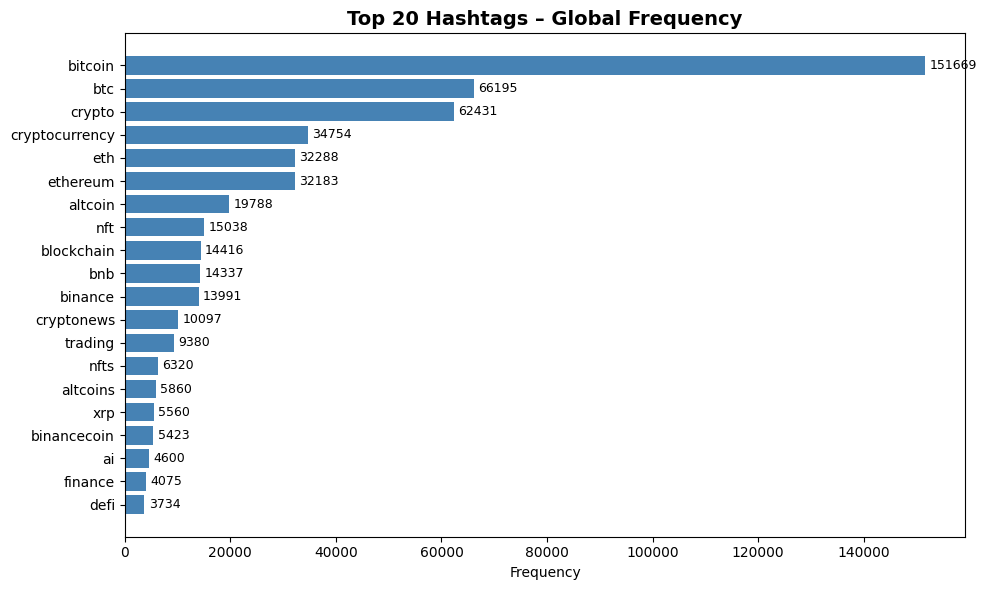

       hashtag  frequency
       bitcoin     151669
           btc      66195
        crypto      62431
cryptocurrency      34754
           eth      32288
      ethereum      32183
       altcoin      19788
           nft      15038
    blockchain      14416
           bnb      14337
       binance      13991
    cryptonews      10097
       trading       9380
          nfts       6320
      altcoins       5860
           xrp       5560
   binancecoin       5423
            ai       4600
       finance       4075
          defi       3734


In [15]:
# Empiezo con el top 20 global para ver las etiquetas mas repetidas.
top20 = overall.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top20['hashtag'][::-1], top20['frequency'][::-1], color='steelblue')
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.set_xlabel('Frequency')
ax.set_title('Top 20 Hashtags – Global Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top20_hashtags.png', dpi=150, bbox_inches='tight')
plt.show()
print(top20.to_string(index=False))

In [16]:
# Aqui miro usuarios con mas uso de hashtags para intuir posibles bots.
user_totals = (
    by_user.groupby('user_name', as_index=False)['frequency']
           .sum()
           .sort_values('frequency', ascending=False)
)

print("Top 15 usuarios por ocurrencias de hashtags (posibles bots):")
print(user_totals.head(15).to_string(index=False))

# Calculo cuanto concentra el top 1% de usuarios en uso total de hashtags.
top1pct = max(1, int(len(user_totals) * 0.01))
total_hashtag_uses = user_totals['frequency'].sum()
top1pct_uses = user_totals.head(top1pct)['frequency'].sum()
print(f"\nTop 1% of users ({top1pct:,}) account for "
      f"{top1pct_uses / total_hashtag_uses * 100:.1f}% of all hashtag uses")

Top 15 usuarios por ocurrencias de hashtags (posibles bots):
                         user_name  frequency
                     Ethereum Yoda      61020
                 BNB Price Tracker      32491
           Trader Jet Telegram Bot      22426
Trackify | #1 BTC Price Action Bot      20832
                    Crypto Alerted      17237
                Documenting Crypto      17211
               Bitcoin Printer on🔺      13589
                 Live Price Crypto       9862
                      Whales Radar       9135
           waarkoopikmijncrypto.nl       7853
                       Crypto Frog       7584
                       Alpha Trade       7196
                cryptowise.finance       6364
                 TerryTheTipsterSA       6004
                           COINRBI       4985

Top 1% of users (362) account for 57.1% of all hashtag uses


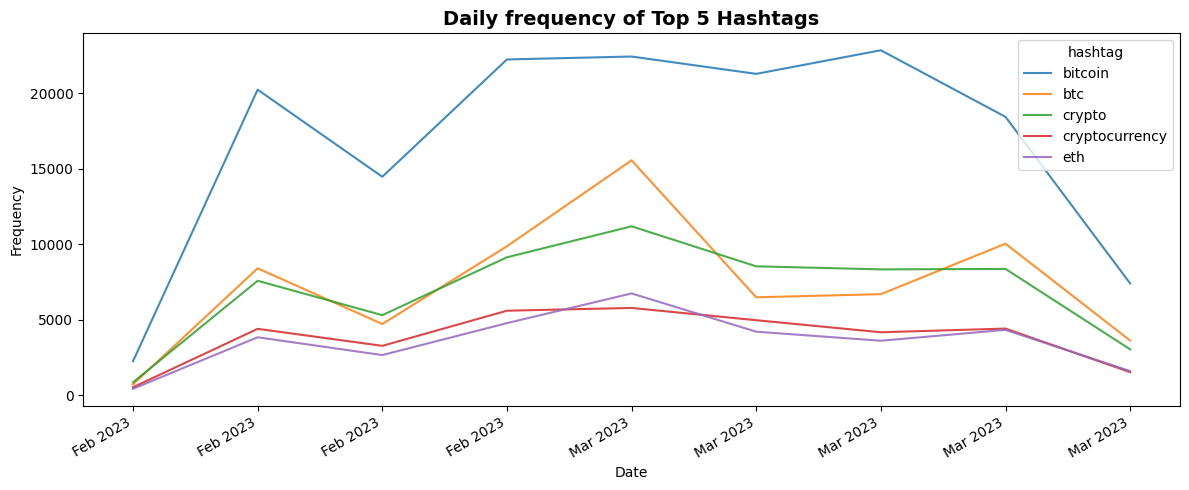

In [17]:
# Me quedo con los top hashtags y miro su evolucion diaria.
TOP_N_TAGS = 5
top_tags = overall.head(TOP_N_TAGS)['hashtag'].tolist()

pivot = (
    by_date[by_date['hashtag'].isin(top_tags)]
    .pivot_table(index='date', columns='hashtag', values='frequency', aggfunc='sum')
    .fillna(0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot(ax=ax, linewidth=1.5, alpha=0.85)
ax.set_title(f'Daily frequency of Top {TOP_N_TAGS} Hashtags', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('hashtag_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Wordcloud de hashtags
Genero una nube de palabras (wordcloud) con los hashtags más frecuentes para visualizar rápidamente cuáles son los más utilizados en los tweets analizados.

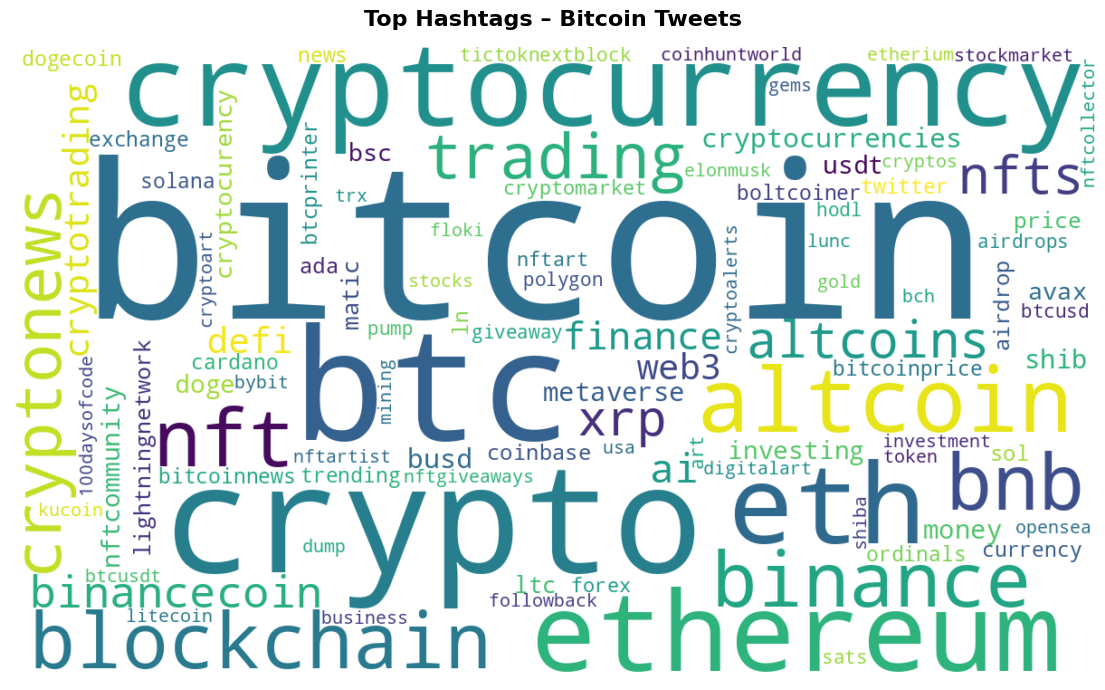

[wordcloud] Saved as 'wordcloud_hashtags.png'


In [18]:
# Reuso el DataFrame overall para evitar recalculos.
extractor.generate_hashtag_wordcloud(overall_df=overall, max_words=100, figsize=(12, 7))

## 7. Wordcloud de palabras frecuentes (sin hashtags)
Hago un análisis adicional para ver el vocabulario general de los tweets, excluyendo hashtags y palabras vacías (stopwords). Así identifico las palabras más relevantes y frecuentes en las conversaciones sobre Bitcoin.

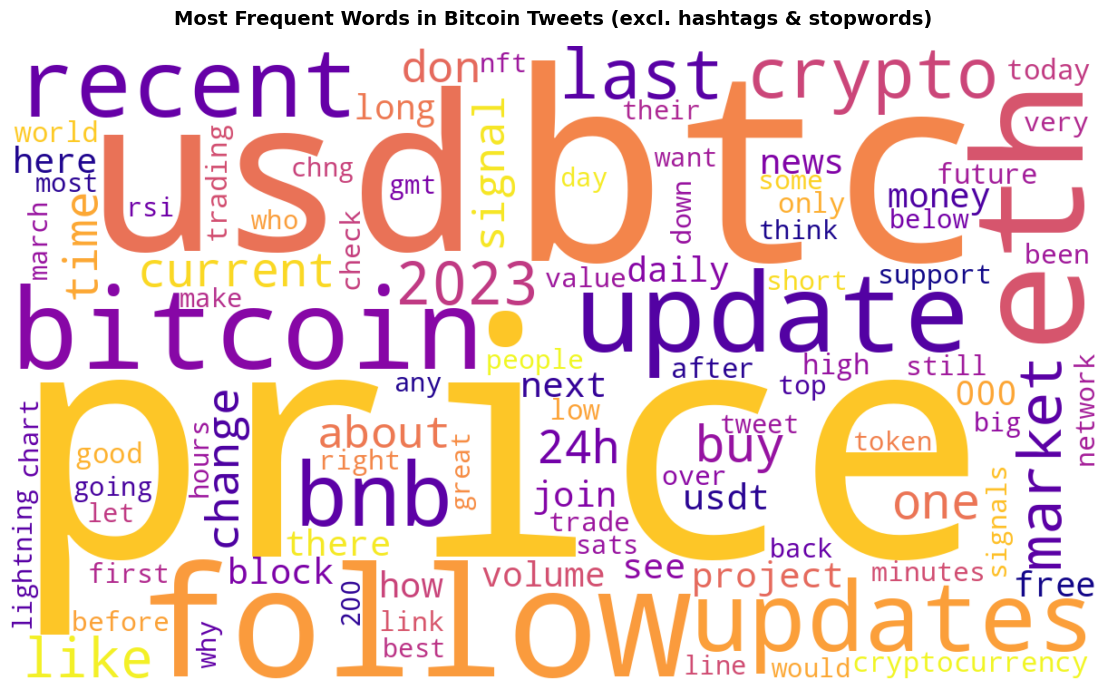

Top 15 words: [('price', 46860), ('btc', 29395), ('usd', 18974), ('follow', 18763), ('eth', 18303), ('bitcoin', 17249), ('update', 16583), ('updates', 14964), ('recent', 14472), ('bnb', 12592), ('crypto', 12102), ('last', 11812), ('2023', 8742), ('market', 8646), ('like', 7067)]


In [19]:
from collections import Counter

# Defino stopwords basicas en ingles y español para limpiar el conteo.
STOPWORDS = {
    'the', 'a', 'an', 'is', 'in', 'it', 'of', 'to', 'and', 'for',
    'on', 'at', 'i', 'this', 'that', 'with', 'are', 'be', 'as',
    'by', 'was', 'has', 'have', 'from', 'or', 'will', 'not', 'you',
    'rt', 'amp', 'de', 'la', 'el', 'en', 'es', 'se', 'lo', 'un',
    'my', 'we', 'he', 'she', 'they', 'but', 'so', 'if', 'its',
    'via', 'all', 'up', 'no', 'do', 'get', 'can', 'now', 'just',
    'more', 'our', 'out', 'new', 'what', 'when', 'than', 'your'
}

# Cuento palabras quitando hashtags y stopwords para ver vocabulario general.
word_counts: Counter = Counter()
for tweet in df['clean_text'].dropna():
    words = [
        w for w in tweet.split()
        if not w.startswith('#')
        and w not in STOPWORDS
        and len(w) > 2
    ]
    word_counts.update(words)

wc = WordCloud(
    width=1200, height=700, max_words=100,
    background_color='white', colormap='plasma',
).generate_from_frequencies(word_counts)

fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Frequent Words in Bitcoin Tweets (excl. hashtags & stopwords)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('wordcloud_words.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 15 words:", word_counts.most_common(15))